<a id="title"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:20px 20px;">**Reference Area Estimation**</p>

## **Method Overview**

Per **branch**: arc length **`gd`**, reference **`A_ref`** from **`Area`**, then **`pct_AS`**. Later: stack branches, **dedupe rounded (Px,Py,Pz)** with **max `pct_AS`**, **3D QA**, exports at **repo root**.

**Inputs:** `results/block2_results/area/<PATIENT_ID>/branches/dataframes` — **`Px`, `Py`, `Pz`, `Area`**.

### Quantities computed

1. **Geodesic distance** `gd` (mm)
2. **Sliding-window reference areas** with `window_size = 10` mm:
   - proximal target: `gd_i - 10`
   - distal target: `gd_i + 10`
   - nearest points in `gd` are used to map `Area_prox` and `Area_dist`
3. **Reference area** (From Ela Burrulls Work)

If either proximal or distal target falls outside branch limits, the corresponding area is `NaN`, so `A_ref` is also `NaN`. This naturally excludes the first and last 10 mm of each branch.

### Downstream steps (final Block 2 phase)

Later sections compute **percent area stenosis (%AS)** from `Area` and `A_ref`, merge all branch paths into a **single patient-level table** using a **maximum %AS per 3D location** rule (to handle overlapping centerline geometry conservatively), produce **3D severity maps** for QA, and export experimental spreadsheets to the **repository root** (not under `results/`) until the pipeline is integrated officially.

<a id="conceptual-background"></a>

## **Reader’s guide: Global vs Branches and  Counts**

- **Global table:** one listing along the packaged whole tree. Computed in block 1 and block 2 area. 
- **Branch tables:** ostium → endpoint paths; shared segments repeat across files.
- **`Branch Area`:** Block 2 sectional areas (global) mapped to branch points with `_map_area_to_df` in `src/blocks/_02_stenosis.py` (row-aligned or KDTree).
- **Merged map:** rounded (Px,Py,Pz) + max `pct_AS`. Merged DF row counts vs Block 1 global need not match.
- **3D QA:** grey polylines per branch; coloured scatter from merged table only.

When we then **merge** branches into `total_df_Normal_1`, we **group by rounded 3D coordinates** and keep **the row with the highest % area stenosis** among duplicates. That removes a large chunk of rows, **many stacked rows were spatial duplicates** (same path region visited by several branch tables).

**Important:** the number of rows after this merge is **not promised to equal** the Block 1 global row count. Reason: **“one row per rounded XYZ among branch points”** is not the same definition as **“one row per sample along the global centreline”**. Different sampling + rounding means the **sets of locations** can differ. Seeing the merged total **smaller than** the global row count (or different RCA/LCA splits) is therefore **not automatically a bug**, it signals different **rules for counting locations**, not necessarily wrong geometry.

---

### **Maximum %AS when paths overlap (clinical “don’t miss the worst” rule)**

Where two branch paths describe the **same place**, %AS might differ slightly (different local reference or path context). For a **conservative** screening-style summary we keep **the worst (highest) %AS** at that spot so we do **not underestimate** narrowing. This notebook’s merged table is **experimental** and does not replace full vessel-level statistics; it is useful for a **single overview map** and QA.

---

### **Where `Area` on each row really comes from?**

Cross-sectional **area** in Block 2 is computed along the **processed full-artery centreline** for each of RCA and LCA (`centerline_*.vtp`): smooth, **resample**, then **VMTK centreline sections** against the lumen surface. That produces a trusted list of **areas tied to that resampled centreline**.

Your tables (global, artery, **and** each branch) carry Block 1’s own `(Px, Py, Pz)`. Those coordinates are **mapped** onto that reference as follows (see `src/blocks/_02_stenosis.py`, function `_map_area_to_df`):

- If the table’s points **match** the resampled centreline **in order and numerically** → areas are copied **row by row** (**`row_aligned`**).
- Otherwise → for **each** spreadsheet point we take the **nearest neighbour** on the reference centreline in 3D and assign **that neighbour’s area** (**`kdtree`** / nearest-point mapping).

So branch points do **not** need to be identical to global points: **both** get their `Area` from the **same physics** (sections on the artery centreline), then **transferred** by identity or by **proximity**. Global and branch files are **not** linked by “copy column from global to branch” inside the pipeline.

**Caveat:** nearest-neighbour assignment is usually fine when the branch centreline lies close to the main extracted centreline; if a point drifts far sideways, the closest reference sample might be **less representative** — worth keeping in mind for thesis limitations.

---

### **Visual hints in this notebook**

- **Unified 3D plot:** branch paths are drawn as **separate grey polylines** (each path keeps correct connectivity). Coloured dots come from the **merged** table — **never** one single polyline through merged rows, which would falsely connect unrelated segments.

<a id="step1"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">1. Imports & Configuration</p>

In [1]:
# Purpose: import dependencies and define runtime configuration.
from pathlib import Path

import numpy as np
import pandas as pd

PATIENT_ID = "Normal_1"
window_size = 10.0  # mm

PROJECT_ROOT = Path.cwd().resolve().parents[1]
BRANCH_DF_DIR = PROJECT_ROOT / "results" / "block2_results" / "area" / PATIENT_ID / "branches" / "dataframes"
OUTPUT_DIR = PROJECT_ROOT  # experimental output at repository root

print(f"Patient ID     : {PATIENT_ID}")
print(f"Branch DF dir  : {BRANCH_DF_DIR} (exists={BRANCH_DF_DIR.exists()})")
print(f"Window size    : {window_size} mm")
print(f"Output dir     : {OUTPUT_DIR}")

Patient ID     : Normal_1
Branch DF dir  : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block2_results\area\Normal_1\branches\dataframes (exists=True)
Window size    : 10.0 mm
Output dir     : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository


<a id="step2"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">2. Data Loading & Branch Discovery</p>

This section auto-discovers branch files (`.xlsx` preferred, `.csv` fallback), validates required columns, and loads each branch dataframe into a dictionary keyed by branch name.

In [ ]:
# Purpose: discover branch files and load validated input dataframes.
def get_branch_name(file_path: Path) -> str:
    name = file_path.stem
    for suffix in ["_area", "_areas", "_sectional_area"]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]
    return name


def discover_branch_files(branch_dir: Path):
    if not branch_dir.exists():
        raise FileNotFoundError(
            f"Branch directory does not exist: {branch_dir}\n"
            "Update BRANCH_DF_DIR to your actual location."
        )

    xlsx_files = sorted(branch_dir.glob("*.xlsx"))
    csv_files = sorted(branch_dir.glob("*.csv"))

    if xlsx_files:
        return xlsx_files, "xlsx"
    if csv_files:
        return csv_files, "csv"

    raise FileNotFoundError(
        f"No .xlsx or .csv branch files found in: {branch_dir}"
    )


def load_branch_dataframe(file_path: Path) -> pd.DataFrame:
    if file_path.suffix.lower() == ".xlsx":
        df = pd.read_excel(file_path)
    elif file_path.suffix.lower() == ".csv":
        df = pd.read_csv(file_path)
    else:
        raise ValueError(f"Unsupported extension: {file_path.suffix}")

    required_cols = {"Px", "Py", "Pz", "Area"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"{file_path.name} is missing columns: {sorted(missing_cols)}")

    return df


branch_files, source_format = discover_branch_files(BRANCH_DF_DIR)
branch_data = {}

for file_path in branch_files:
    branch_name = get_branch_name(file_path)
    branch_data[branch_name] = load_branch_dataframe(file_path)

print(f"Detected {len(branch_data)} branches from {source_format.upper()} files:")
for branch_name, branch_df in branch_data.items():
    print(f"- {branch_name}: {len(branch_df)} points")

Detected 11 branches from XLSX files:
- dataset_LCA_B01_Normal_1: 822 points
- dataset_LCA_B02_Normal_1: 425 points
- dataset_LCA_B03_Normal_1: 583 points
- dataset_LCA_B04_Normal_1: 575 points
- dataset_LCA_B05_Normal_1: 335 points
- dataset_LCA_B06_Normal_1: 316 points
- dataset_LCA_B07_Normal_1: 243 points
- dataset_RCA_B01_Normal_1: 1065 points
- dataset_RCA_B02_Normal_1: 1362 points
- dataset_RCA_B03_Normal_1: 1031 points
- dataset_RCA_B04_Normal_1: 530 points


<a id="step3"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">3. Geodesic Distance & Sliding-Window Reference Area</p>

For each branch dataframe:

- compute cumulative `gd` from ordered points (`Px`, `Py`, `Pz`),
- locate nearest points to `gd ± 10 mm`,
- map `Area_prox` and `Area_dist`,
- compute `A_ref` as their mean with standard NaN propagation.

In [3]:
# Purpose: compute gd, sliding-window references, and per-branch A_ref summaries.
def nearest_index_within_bounds(gd_values: np.ndarray, target_values: np.ndarray) -> np.ndarray:
    """
    Return nearest indices in gd_values for each target in target_values.
    Targets outside gd range are marked with -1.
    """
    idx = np.searchsorted(gd_values, target_values)
    idx = np.clip(idx, 0, len(gd_values) - 1)

    prev_idx = np.clip(idx - 1, 0, len(gd_values) - 1)

    dist_prev = np.abs(gd_values[prev_idx] - target_values)
    dist_curr = np.abs(gd_values[idx] - target_values)

    nearest_idx = np.where(dist_prev <= dist_curr, prev_idx, idx)

    out_of_bounds = (target_values < gd_values[0]) | (target_values > gd_values[-1])
    nearest_idx[out_of_bounds] = -1

    return nearest_idx

def compute_reference_columns(df_branch: pd.DataFrame, window_mm: float) -> pd.DataFrame:
    df_out = df_branch.copy()

    xyz = df_out[["Px", "Py", "Pz"]].to_numpy(dtype=float)
    delta_xyz = np.diff(xyz, axis=0)
    step_dist = np.linalg.norm(delta_xyz, axis=1)
    step_dist = np.insert(step_dist, 0, 0.0)

    df_out["gd"] = np.cumsum(step_dist)

    gd_vals = df_out["gd"].to_numpy(dtype=float)
    area_vals = df_out["Area"].to_numpy(dtype=float)

    prox_targets = gd_vals - window_mm
    dist_targets = gd_vals + window_mm

    prox_idx = nearest_index_within_bounds(gd_vals, prox_targets)
    dist_idx = nearest_index_within_bounds(gd_vals, dist_targets)

    area_prox = np.full(len(df_out), np.nan, dtype=float)
    area_dist = np.full(len(df_out), np.nan, dtype=float)

    prox_valid = prox_idx >= 0
    dist_valid = dist_idx >= 0

    area_prox[prox_valid] = area_vals[prox_idx[prox_valid]]
    area_dist[dist_valid] = area_vals[dist_idx[dist_valid]]

    df_out["Area_prox"] = area_prox
    df_out["Area_dist"] = area_dist
    df_out["A_ref"] = (df_out["Area_prox"] + df_out["Area_dist"]) / 2.0

    return df_out

processed_branch_data = {}

for branch_name, branch_df in branch_data.items():
    processed_branch_data[branch_name] = compute_reference_columns(
        branch_df,
        window_mm=window_size,
    )

first_branch_name = next(iter(processed_branch_data))
first_branch_df = processed_branch_data[first_branch_name]

valid_mask = first_branch_df["A_ref"].notna()
valid_pct = 100.0 * valid_mask.mean()
nan_pct = 100.0 - valid_pct

print(f"Verification branch: {first_branch_name}")
print(f"A_ref valid points: {valid_pct:.2f}%")
print(f"A_ref NaN points  : {nan_pct:.2f}%")

summary_df = pd.DataFrame(
    [
        {
            "branch": branch_name,
            "n_points": len(df_branch),
            "n_valid_A_ref": int(df_branch["A_ref"].notna().sum()),
            "n_nan_A_ref": int(df_branch["A_ref"].isna().sum()),
        }
        for branch_name, df_branch in processed_branch_data.items()
    ]
)

summary_df

Verification branch: dataset_LCA_B01_Normal_1
A_ref valid points: 83.45%
A_ref NaN points  : 16.55%


,branch,n_points,n_valid_A_ref,n_nan_A_ref
0,dataset_LCA_B01_Normal_1,822,686,136
1,dataset_LCA_B02_Normal_1,425,304,121
2,dataset_LCA_B03_Normal_1,583,466,117
3,dataset_LCA_B04_Normal_1,575,455,120
4,dataset_LCA_B05_Normal_1,335,211,124
5,dataset_LCA_B06_Normal_1,316,200,116
6,dataset_LCA_B07_Normal_1,243,125,118
7,dataset_RCA_B01_Normal_1,1065,936,129
8,dataset_RCA_B02_Normal_1,1362,1239,123
9,dataset_RCA_B03_Normal_1,1031,898,133


<a id="step4"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">4. Export Enriched Branch DataFrames</p>

Each processed branch is exported to the repository root as an experimental `.xlsx` file containing the new columns:

- `gd`
- `Area_prox`
- `Area_dist`
- `A_ref`

In [4]:
# Purpose: export per-branch reference-value tables and preview one branch.
exported_files = []

for branch_name, df_branch in processed_branch_data.items():
    output_name = f"{PATIENT_ID}_{branch_name}_reference_values.xlsx"
    output_path = OUTPUT_DIR / output_name
    df_branch.to_excel(output_path, index=False)
    exported_files.append(output_path)

print("Export completed:")
for output_path in exported_files:
    print(f"- {output_path}")

preview_branch_name = first_branch_name
print(f"\nPreview of branch: {preview_branch_name}")
processed_branch_data[preview_branch_name].head()

Export completed:
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B01_Normal_1_reference_values.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B02_Normal_1_reference_values.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B03_Normal_1_reference_values.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B04_Normal_1_reference_values.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B05_Normal_1_reference_values.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B06_Normal_1_reference_values.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B07_Normal_1_reference_values.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_RCA_B01_Normal_1_reference_values.xlsx
- C:\Users\adria\OneDr

,Sample_ID,Artery_Type,Branch_ID,Path_Point_Index,Px,Py,Pz,Radius,PointType,Area,gd,Area_prox,Area_dist,A_ref
0,1,LCA,LCA_B01,0,221.379944,242.227921,-91.906563,2.074208,Ostium,24.449387,0.000000,NaN,21.951380,NaN
1,1,LCA,LCA_B01,1,221.518311,242.255295,-91.899139,2.157079,Standard,23.094696,0.141244,NaN,24.636494,NaN
2,1,LCA,LCA_B01,2,221.518860,242.255402,-91.899109,2.157411,Standard,23.094696,0.141804,NaN,24.636494,NaN
3,1,LCA,LCA_B01,3,221.521317,242.257904,-91.896332,2.156677,Standard,23.094696,0.146277,NaN,24.636494,NaN
4,1,LCA,LCA_B01,4,221.791122,242.526337,-91.656708,2.104106,Standard,16.225379,0.596023,NaN,27.313295,NaN


<a id="step5"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">5. Percent Area Stenosis (%AS)</p>

For each centerline point with a valid reference area, we apply the standard **area stenosis** definition from Els Burrull's Work.

- Where **`A_ref` is `NaN`** (10 mm exclusion zones or missing reference), **`pct_AS` stays `NaN`**: we do not impute, so quantification is only defined on the interior of each branch path.
- **Division safety:** if `A_ref` is zero or negligible, the ratio is undefined; we set **`pct_AS` to `NaN`** instead of producing `inf` or unstable values.

The dataframe column name is `pct_AS` (Python-safe); in text we refer to it as **%AS**.


In [5]:
# Purpose: compute % area stenosis (pct_AS) with safe NaN/zero handling.
A_REF_EPS = 1e-12

def add_pct_as(df_branch: pd.DataFrame, eps: float = A_REF_EPS) -> pd.DataFrame:
    """Append % area stenosis (pct_AS). NaN A_ref and near-zero A_ref yield NaN pct_AS."""
    df_out = df_branch.copy()
    a_ref = df_out["A_ref"]
    area = df_out["Area"]
    valid = a_ref.notna() & (a_ref.abs() > eps)

    ratio = np.full(len(df_out), np.nan, dtype=float)
    ratio[valid.to_numpy()] = np.asarray((area / a_ref).loc[valid], dtype=float)
    df_out["pct_AS"] = (1.0 - ratio) * 100.0

    return df_out

for _branch_key in list(processed_branch_data.keys()):
    processed_branch_data[_branch_key] = add_pct_as(processed_branch_data[_branch_key])

_pct_summary = pd.DataFrame(
    [
        {
            "branch": _k,
            "n_points": len(_df),
            "n_valid_pct_AS": int(_df["pct_AS"].notna().sum()),
        }
        for _k, _df in processed_branch_data.items()
    ]
)
_pct_summary


,branch,n_points,n_valid_pct_AS
0,dataset_LCA_B01_Normal_1,822,686
1,dataset_LCA_B02_Normal_1,425,304
2,dataset_LCA_B03_Normal_1,583,466
3,dataset_LCA_B04_Normal_1,575,455
4,dataset_LCA_B05_Normal_1,335,211
5,dataset_LCA_B06_Normal_1,316,200
6,dataset_LCA_B07_Normal_1,243,125
7,dataset_RCA_B01_Normal_1,1065,936
8,dataset_RCA_B02_Normal_1,1362,1239
9,dataset_RCA_B03_Normal_1,1031,898


<a id="step6"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">6. Global Dataset (Clinical Maximum %AS)</p>

Coronary **branch paths overlap in space**: the same physical segment (for example left main or proximal LAD) can appear as rows in **several** `dataset_*` tables, each with its own path-local `gd`, `A_ref`, and thus `pct_AS`. If we simply concatenated tables, duplicated coordinates could be summarized in different ways; for **stenosis screening** we adopt a **maximum-severity** rule.

**Rationale:** Among duplicate locations, we keep the row with the **highest `pct_AS`**. This is a **conservative** choice: it avoids **underestimating** focal narrowing when one path assigns a more favorable reference than another. It does **not** resolve true vessel topology or branch labels—it is an **experimental fusion** for a single patient-level map and for visualization before full pipeline integration.

**Implementation:** We stack all branch tables with a `source_branch` column, define a rounded 3D key (`_Px_g`, `_Py_g`, `_Pz_g`) so near-identical coordinates from different paths match, then **sort by `pct_AS` descending** (missing values last) and **`drop_duplicates`** on that key keeping the first row—equivalent to taking the max `pct_AS` per location when at least one value is finite. Groups where **all** `pct_AS` are `NaN` retain one arbitrary representative row (still a valid spatial sample, but stenosis is undefined there).

In [6]:
# Purpose: merge branches into one global table using max pct_AS per location.
COORD_ROUND = 6

branch_frames = []
for _name, _df in processed_branch_data.items():
    branch_frames.append(_df.assign(source_branch=_name))

total_concat = pd.concat(branch_frames, ignore_index=True)

total_concat["_Px_g"] = np.round(total_concat["Px"].to_numpy(dtype=float), COORD_ROUND)
total_concat["_Py_g"] = np.round(total_concat["Py"].to_numpy(dtype=float), COORD_ROUND)
total_concat["_Pz_g"] = np.round(total_concat["Pz"].to_numpy(dtype=float), COORD_ROUND)

_dedup_subset = ["_Px_g", "_Py_g", "_Pz_g"]

total_df_Normal_1 = (
    total_concat.sort_values("pct_AS", ascending=False, na_position="last")
    .drop_duplicates(subset=_dedup_subset, keep="first")
    .drop(columns=_dedup_subset)
    .reset_index(drop=True)
)

print(f"Rows stacked (all branches): {len(total_concat)}")
print(f"Unique rounded locations:    {len(total_df_Normal_1)}")
print(f"Global valid pct_AS:         {total_df_Normal_1['pct_AS'].notna().sum()} / {len(total_df_Normal_1)}")

total_df_Normal_1.head()


Rows stacked (all branches): 7287
Unique rounded locations:    4251
Global valid pct_AS:         3441 / 4251


,Sample_ID,Artery_Type,Branch_ID,Path_Point_Index,Px,Py,Pz,Radius,PointType,Area,gd,Area_prox,Area_dist,A_ref,pct_AS,source_branch
0,1,LCA,LCA_B07,140,240.218994,242.251404,-95.349609,0.529062,Standard,1.046450,21.825682,30.665889,0.470026,15.567957,93.278182,dataset_LCA_B07_Normal_1
1,1,LCA,LCA_B07,141,240.229614,242.247955,-95.355995,0.531156,Standard,1.046450,21.838545,30.665889,0.470026,15.567957,93.278182,dataset_LCA_B07_Normal_1
2,1,LCA,LCA_B07,144,240.592117,242.234665,-95.555275,0.583954,Standard,1.160224,22.254527,33.209372,0.717954,16.963663,93.160535,dataset_LCA_B07_Normal_1
3,1,LCA,LCA_B07,143,240.495453,242.233032,-95.504036,0.566606,Standard,1.121457,22.145110,32.123205,0.668415,16.395810,93.160101,dataset_LCA_B07_Normal_1
4,1,LCA,LCA_B07,139,240.012558,242.272339,-95.193405,0.525545,Standard,0.947668,21.565963,26.889959,0.404157,13.647058,93.055878,dataset_LCA_B07_Normal_1


<a id="step7"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">7. 3D Visualization (Severity-Colored Centerlines)</p>

Visual QA follows **the same philosophy as Notebook 04 (sectional Area)**: **`pyvista.Plotter`**, artery **surface meshes at low opacity** so the vessel tree shape matches the Area figures and **scatter points** along the ordered centerline, colored by a clinical scalar.

Encoding:

- **`pct_AS`** (column from section 5 **% area stenosis**) on each point using a **green → yellow → red** colormap with fixed limits **\[0, 100\]** %.

- **`NaN`** `pct_AS` (10 mm exclusions, undefined reference): points still appear using PyVista’s **`nan_color`** (`lightgray`) so the geometry remains visible outside the quantifiable band.

Each **single-branch** view includes a faint **polyline backbone** along that branch’s row order (ostium→endpoint). The **unified** view must **not** connect `total_df_Normal_1` row-to-row (those rows mix many branches and deduplicated sites), which would draw spurious chords across the tree; instead it draws **one backbone per branch** from `processed_branch_data` and colors **only** the merged `total_df_Normal_1` points by `%AS`.

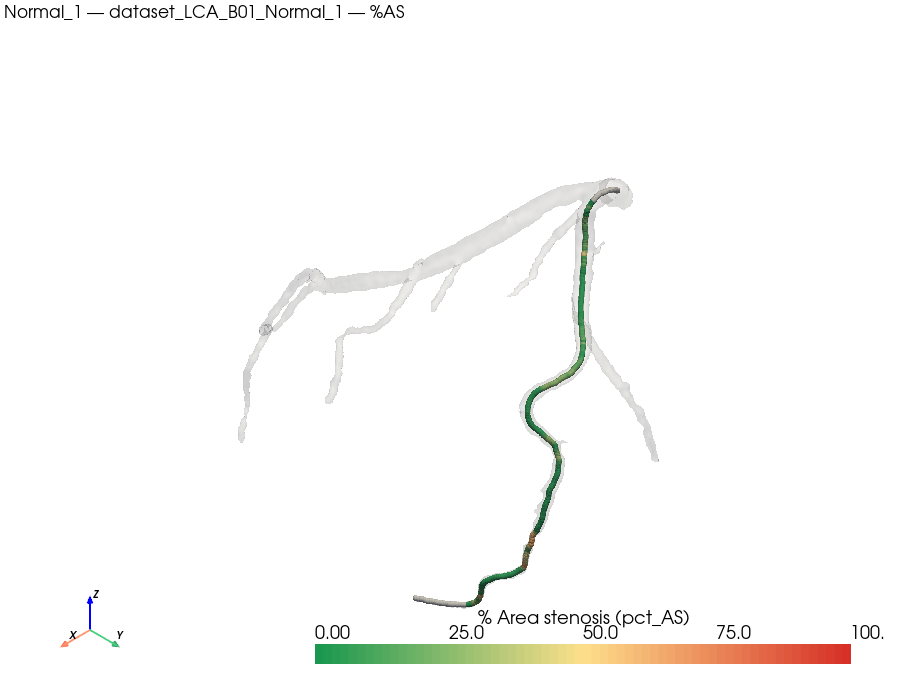

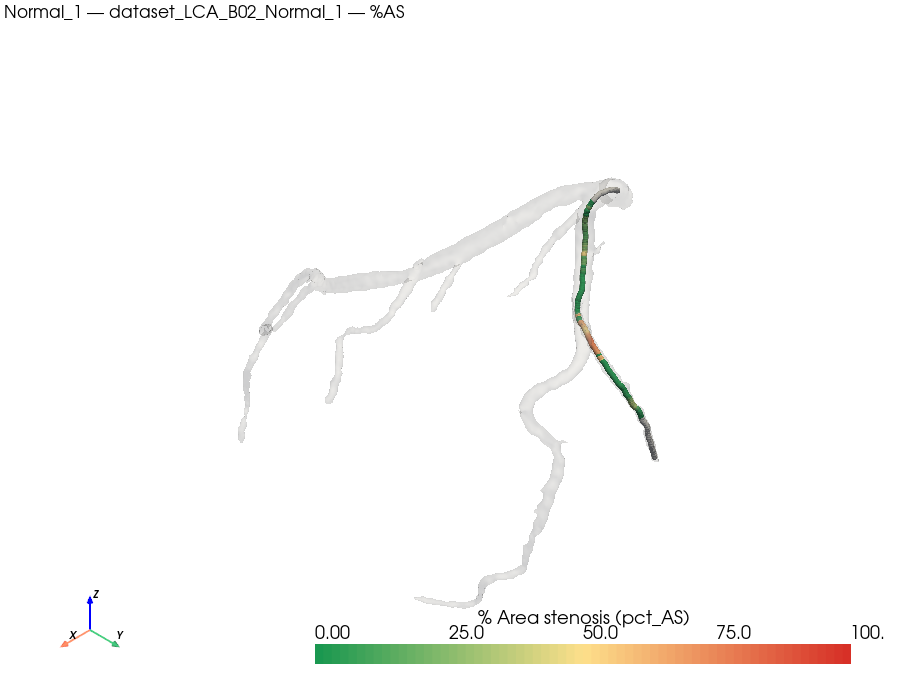

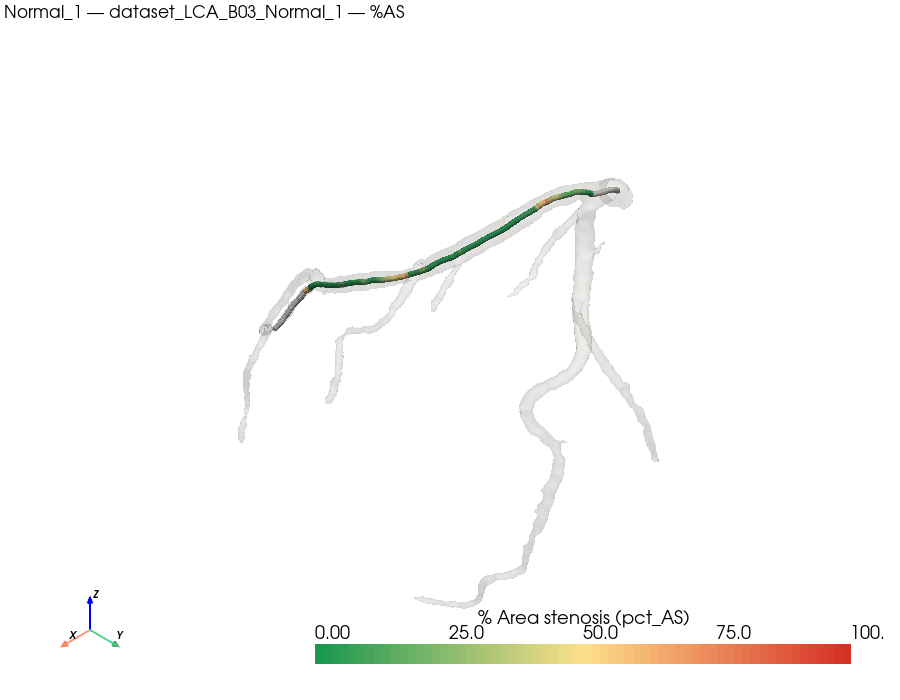

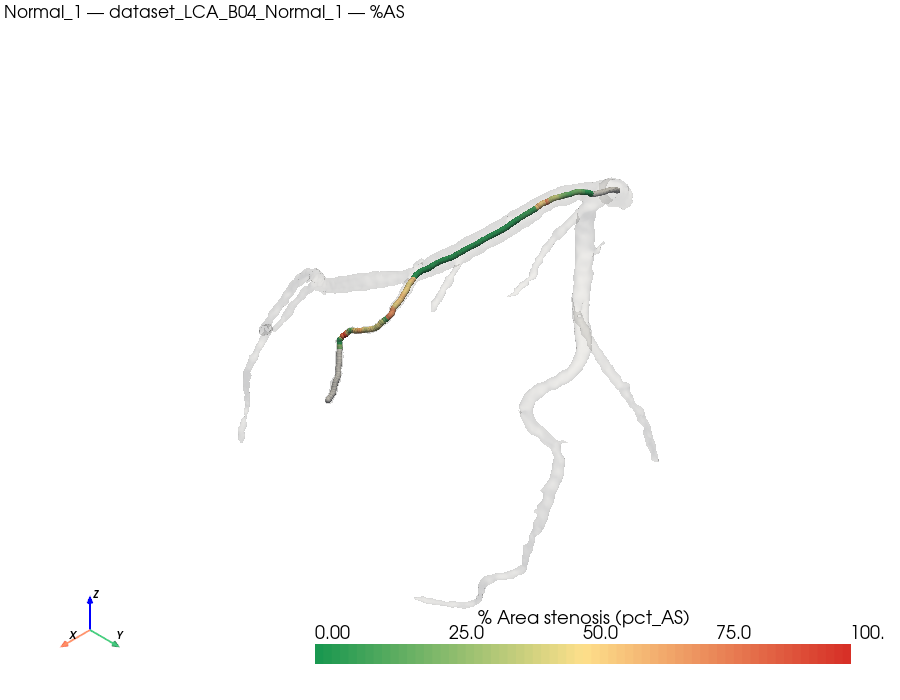

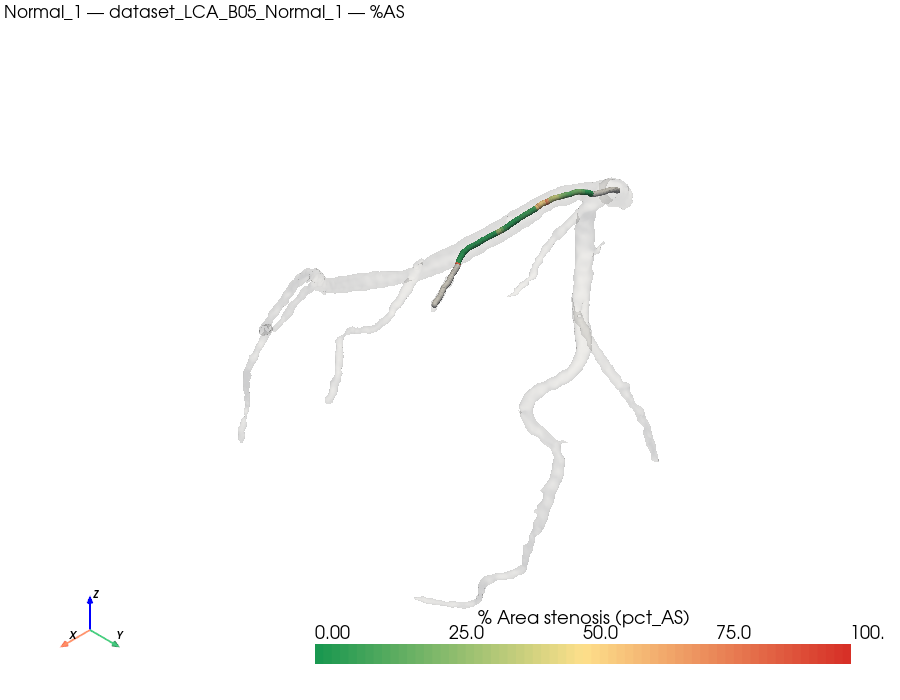

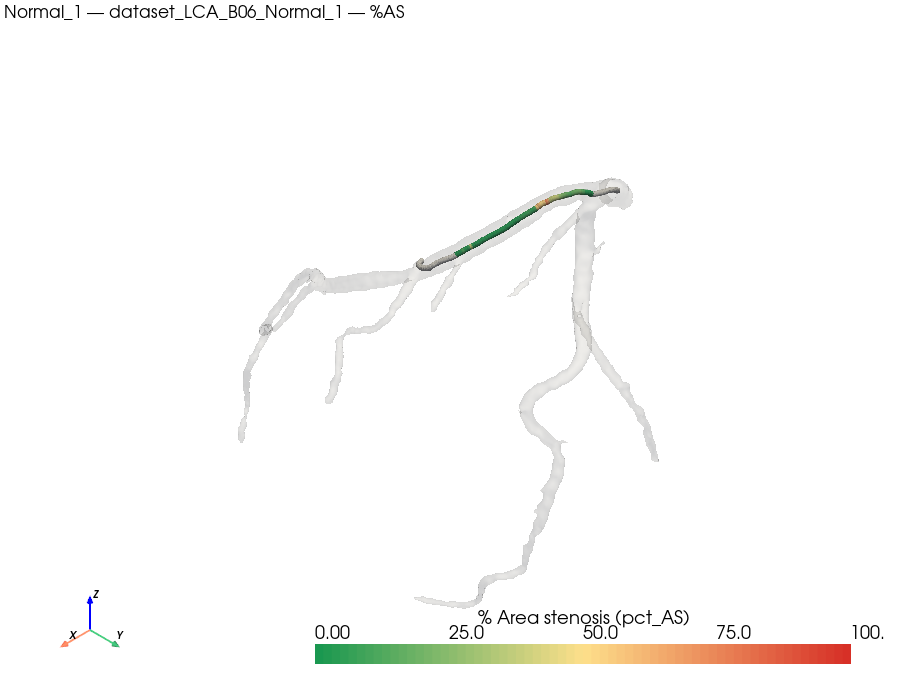

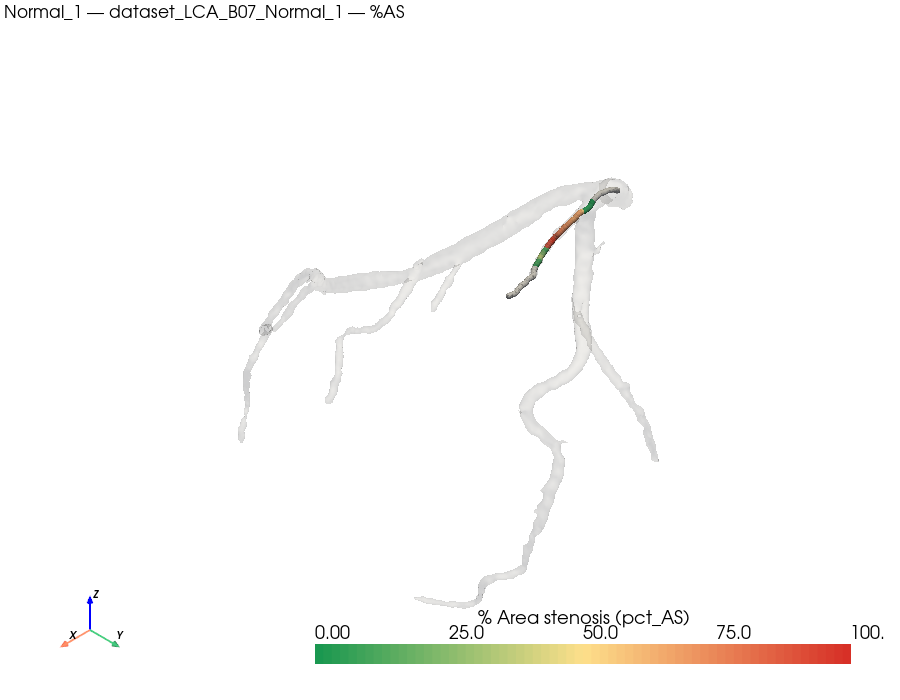

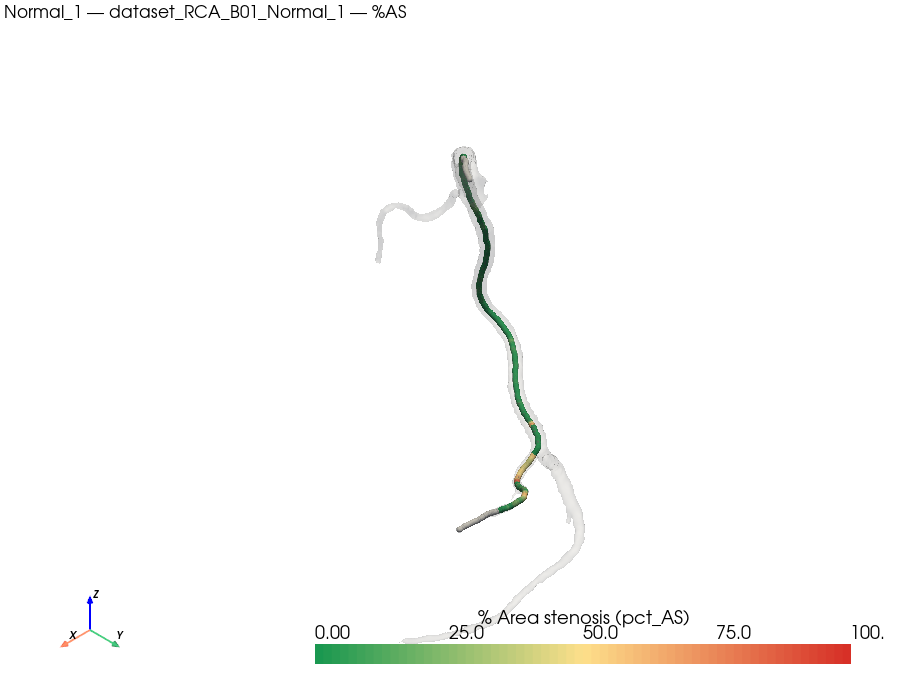

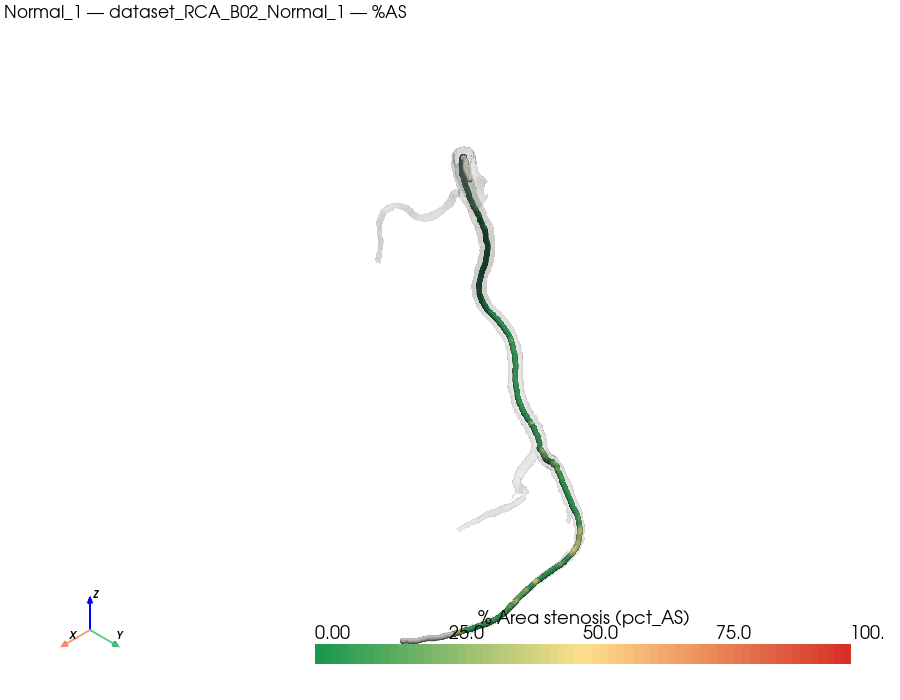

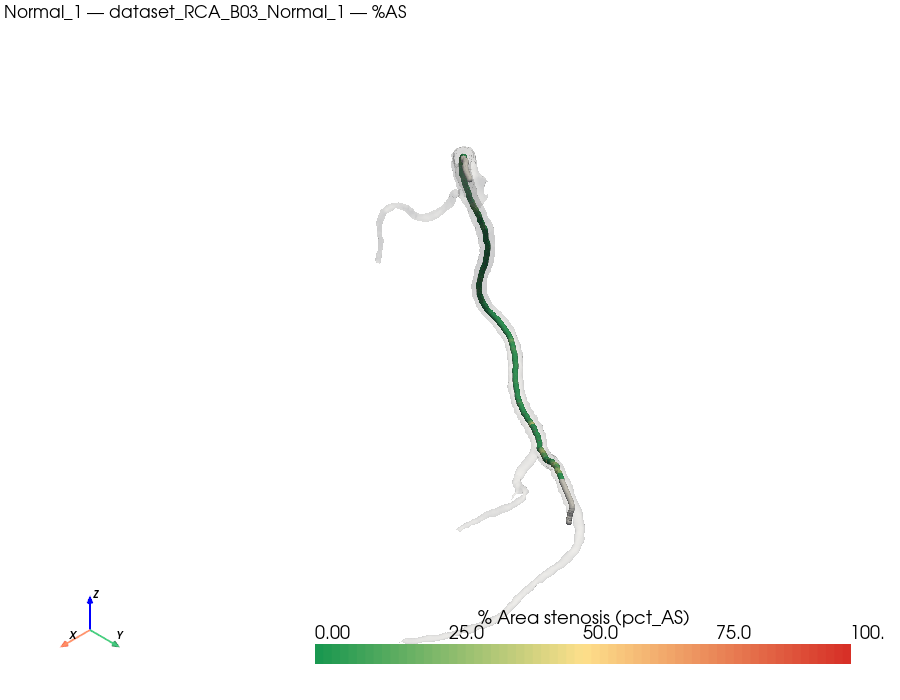

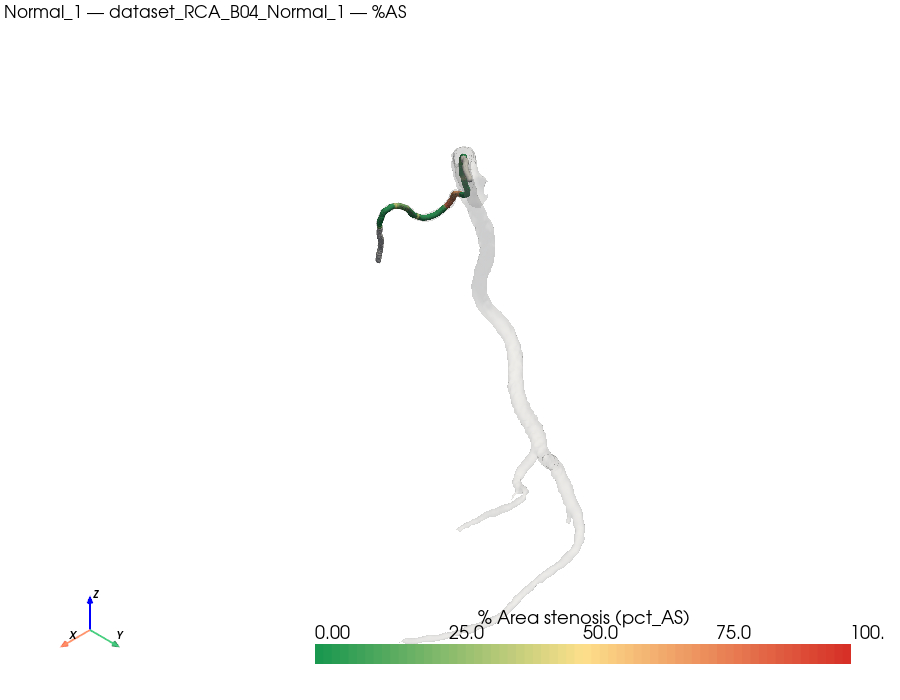

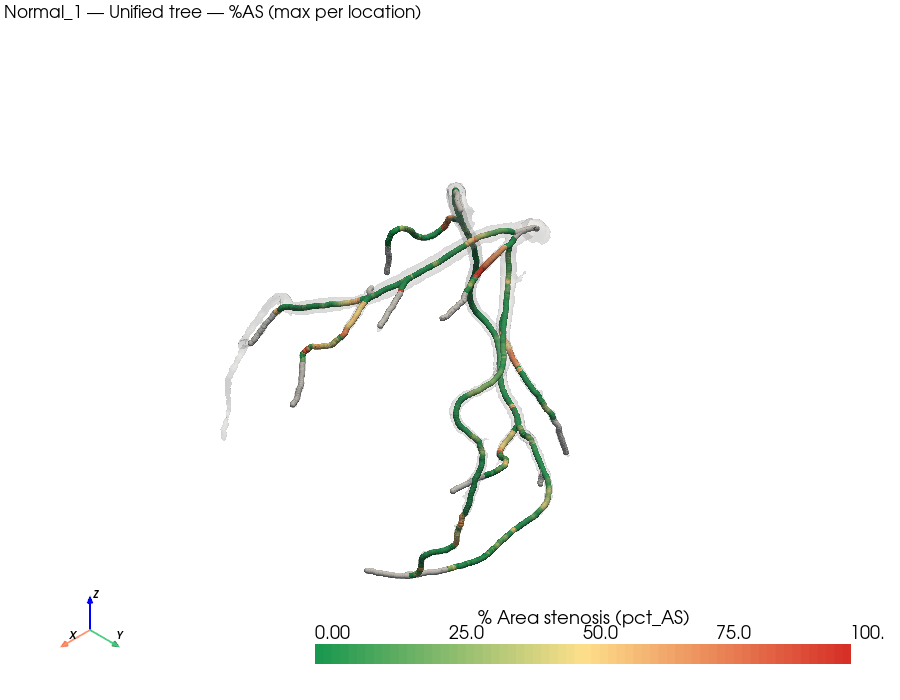

In [8]:
# Purpose: render branch and unified 3D %AS maps with shared styling.
import sys
import types
import numpy as np
import pyvista as pv
from matplotlib.colors import LinearSegmentedColormap

# PyVista / VTK: avoid importing optional vtkRenderingMatplotlib in some conda builds.
sys.modules.setdefault(
    "vtkmodules.vtkRenderingMatplotlib",
    types.ModuleType("vtkmodules.vtkRenderingMatplotlib"),
)

for _pv_backend in ("trame", "static"):
    try:
        pv.set_jupyter_backend(_pv_backend)
        break
    except Exception:
        continue

BLOCK1_SAMPLE_DIR = PROJECT_ROOT / "results" / "block1_results" / PATIENT_ID

PCT_AS_VMIN = 0.0
PCT_AS_VMAX = 100.0

green_yellow_red_stenosis = LinearSegmentedColormap.from_list(
    "pct_as_gyr", ["#1a9850", "#fee08b", "#d73027"], N=64
)

def load_artery_surface_meshes() -> dict[str, pv.PolyData]:
    meshes: dict[str, pv.PolyData] = {}
    for _artery in ("RCA", "LCA"):
        _p = BLOCK1_SAMPLE_DIR / f"surface_{_artery}.vtp"
        if _p.exists():
            meshes[_artery] = pv.read(str(_p))
    return meshes

def infer_artery_type(branch_or_df_name: str, df_plot: pd.DataFrame | None = None) -> str | None:
    if df_plot is not None and "Artery_Type" in df_plot.columns and len(df_plot) > 0:
        v = df_plot["Artery_Type"].iloc[0]
        if pd.notna(v):
            sv = str(v).strip().upper()
            if sv in ("RCA", "LCA"):
                return sv
    bn = branch_or_df_name.upper()
    if "LCA" in bn:
        return "LCA"
    if "RCA" in bn:
        return "RCA"
    return None

def plot_pct_as_tree_pyvista(
    df_plot: pd.DataFrame,
    title: str,
    surfaces: dict[str, pv.PolyData],
    surface_keys: tuple[str, ...],
    *,
    ordered_branch_paths: dict[str, pd.DataFrame] | None = None,
    window_size=(900, 700),
):
    """Render optional hulls, gray centerline tube(s), and colored point cloud.

    If ``ordered_branch_paths`` is set (unified-tree mode), one polyline is drawn
    per branch dict entry in **path order** — never a single line through the
    concatenated global table, which would incorrectly connect unrelated segments.
    """
    plotter = pv.Plotter(window_size=window_size)
    plotter.set_background("white")

    pts = df_plot[["Px", "Py", "Pz"]].to_numpy(dtype=float)
    pct = df_plot["pct_AS"].to_numpy(dtype=float)

    for _sk in surface_keys:
        surf = surfaces.get(_sk)
        if surf is not None:
            plotter.add_mesh(
                surf,
                opacity=0.15,
                color="lightgray",
                show_edges=False,
                smooth_shading=True,
                name=f"hull_{_sk}",
            )

    # Gray backbone: one continuous line only when df_plot rows are one ordered path.
    # Unified ``total_df`` is *not* a single path → use ``ordered_branch_paths``.
    if ordered_branch_paths is not None:
        for _bpath_name in sorted(ordered_branch_paths.keys()):
            bb = ordered_branch_paths[_bpath_name][["Px", "Py", "Pz"]].to_numpy(dtype=float)
            if bb.shape[0] >= 2:
                _ln = pv.lines_from_points(bb, close=False)
                plotter.add_mesh(
                    _ln,
                    color="dimgray",
                    line_width=4,
                    opacity=0.35,
                    render_lines_as_tubes=True,
                    name=f"backbone_{_bpath_name}",
                )
    elif pts.shape[0] >= 2:
        backbone = pv.lines_from_points(pts, close=False)
        plotter.add_mesh(
            backbone,
            color="dimgray",
            line_width=4,
            opacity=0.40,
            render_lines_as_tubes=True,
            name="centerline_backbone",
        )

    cloud = pv.PolyData(pts)
    cloud["pct_AS"] = pct

    plotter.add_mesh(
        cloud,
        scalars="pct_AS",
        cmap=green_yellow_red_stenosis,
        clim=[PCT_AS_VMIN, PCT_AS_VMAX],
        point_size=6,
        render_points_as_spheres=True,
        nan_color="lightgray",
        scalar_bar_args={"title": "% Area stenosis (pct_AS)"},
    )

    plotter.add_text(title, font_size=11, color="black")
    plotter.add_axes()
    plotter.camera_position = "iso"
    plotter.show()


artery_hulls = load_artery_surface_meshes()
if not artery_hulls:
    print(
        f"[PyVista] No surface .vtp files under {BLOCK1_SAMPLE_DIR} — "
        "plots use backbone + points only (same coordinates as Block 1)."
    )

for _branch_name in sorted(processed_branch_data.keys()):
    _dfb = processed_branch_data[_branch_name]
    art = infer_artery_type(_branch_name, _dfb)
    _keys = (art,) if art is not None else tuple()
    plot_pct_as_tree_pyvista(
        _dfb,
        title=f"{PATIENT_ID} — {_branch_name} — %AS",
        surfaces=artery_hulls,
        surface_keys=_keys,
    )

plot_pct_as_tree_pyvista(
    total_df_Normal_1,
    title=f"{PATIENT_ID} — Unified tree — %AS (max per location)",
    surfaces=artery_hulls,
    surface_keys=("RCA", "LCA"),
    ordered_branch_paths=processed_branch_data,
)

In [10]:
# Same as exported total_df_Normal_1.xlsx — merged table from Section 6.
s = total_df_Normal_1["pct_AS"]
print(s.min(), s.max(), s.isna().sum(), (s < 0).sum(), (s > 100).sum())

-679.0490383500646 93.27818235980729 810 1520 0


<a id="step8"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">8. Final Export (Repository Root)</p>

Experimental outputs are written to **`OUTPUT_DIR`** (repository root), not under `results/`, until Block 2 is wired into the main pipeline.

- **Per branch:** one Excel file per branch, including all columns from the reference step **plus** `pct_AS`, named `Normal_1_<branch>_stenosis_complete.xlsx`.
- **Global:** `total_df_Normal_1.xlsx` — unified table after the maximum-%AS deduplication (no temporary `_Px_g` columns; those were dropped in Section 6).


In [11]:
# Purpose: export final branch-level and unified stenosis tables.
_final_branch_exports = []

for _bname, _bdf in processed_branch_data.items():
    _out_path = OUTPUT_DIR / f"{PATIENT_ID}_{_bname}_stenosis_complete.xlsx"
    _bdf.to_excel(_out_path, index=False)
    _final_branch_exports.append(_out_path)

_total_path = OUTPUT_DIR / "total_df_Normal_1.xlsx"
total_df_Normal_1.to_excel(_total_path, index=False)

print("Final stenosis exports:")
for _p in _final_branch_exports:
    print(f"- {_p}")
print(f"- {_total_path}")


Final stenosis exports:
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B01_Normal_1_stenosis_complete.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B02_Normal_1_stenosis_complete.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B03_Normal_1_stenosis_complete.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B04_Normal_1_stenosis_complete.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B05_Normal_1_stenosis_complete.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B06_Normal_1_stenosis_complete.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_LCA_B07_Normal_1_stenosis_complete.xlsx
- C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\Normal_1_dataset_RCA_B01_Normal_1_stenosis_complete.xlsx
- C:\Use